# Decision Tree Regressor from Scratch
## CMOR 438 / INDE 577 — Qiushi Han

A **Decision Tree Regressor** adapts the decision tree algorithm for **continuous targets** instead of class labels. Instead of predicting a class, each leaf node predicts the **mean target value** of training samples that reach it.

We use **variance reduction** as the splitting criterion:

$$VR(S, A) = \text{Var}(S) - \sum_{v} \frac{|S_v|}{|S|} \text{Var}(S_v)$$

The best split is the one that maximizes the reduction in target variance, where it splits the data into subsets where the targets are as similar as possible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split as sklearn_split

from rice_ml.supervised_learning.decision_tree_regressor import DecisionTreeRegressor
from rice_ml.processing.metrics import mean_squared_error, r2_score

## Loading and Exploring the Dataset

We use the **Diabetes dataset** — 442 patients, 10 features, continuous target representing disease progression.

In [2]:
data = load_diabetes()
X, y = data.data, data.target

print(f"Dataset shape: {X.shape}")
print(f"Target range: {y.min():.1f} to {y.max():.1f}")
print(f"Target mean: {y.mean():.2f}")
print(f"Target std: {y.std():.2f}")

Dataset shape: (442, 10)
Target range: 25.0 to 346.0
Target mean: 152.13
Target std: 77.01


## Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = sklearn_split(
    X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 353
Test samples: 89


## Training the Regression Tree

In [4]:
model = DecisionTreeRegressor(max_depth=5)
print("Training Regression Tree...")
model.fit(X_train, y_train)
print("Training Complete.")

Training Regression Tree...
Training Complete.


## Evaluation

In [5]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 3856.66
R² Score: 0.2721


## Comparing Different Tree Depths

Similar to classification trees, depth controls the bias-variance tradeoff in regression.

In [6]:
depths = [1, 2, 3, 5, 7, 10, 15, 20]
train_r2 = []
test_r2 = []

for d in depths:
    m = DecisionTreeRegressor(max_depth=d).fit(X_train, y_train)
    train_r2.append(r2_score(y_train, m.predict(X_train)))
    test_r2.append(r2_score(y_test, m.predict(X_test)))
    print(f"Depth {d:2d} | Train R² = {train_r2[-1]:.4f} | Test R² = {test_r2[-1]:.4f}")

Depth  1 | Train R² = 0.3043 | Test R² = 0.1305
Depth  2 | Train R² = 0.4473 | Test R² = 0.2703
Depth  3 | Train R² = 0.5170 | Test R² = 0.3099
Depth  5 | Train R² = 0.6686 | Test R² = 0.2721
Depth  7 | Train R² = 0.8126 | Test R² = 0.1657
Depth 10 | Train R² = 0.9382 | Test R² = 0.0843
Depth 15 | Train R² = 0.9990 | Test R² = -0.0645
Depth 20 | Train R² = 1.0000 | Test R² = -0.0618


## Visualizing Train vs Test R²

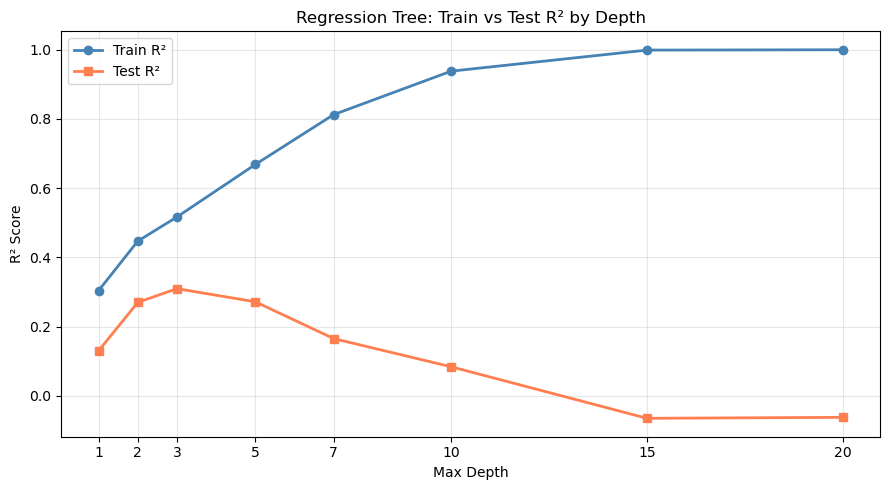

In [7]:
plt.figure(figsize=(9, 5))
plt.plot(depths, train_r2, marker='o', label='Train R²',
         color='steelblue', linewidth=2)
plt.plot(depths, test_r2, marker='s', label='Test R²',
         color='coral', linewidth=2)
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.title('Regression Tree: Train vs Test R² by Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(depths)
plt.tight_layout()
plt.show()

## Predicted vs Actual Values

Visualize how well the regression tree predictions align with actual diabetes progression values.

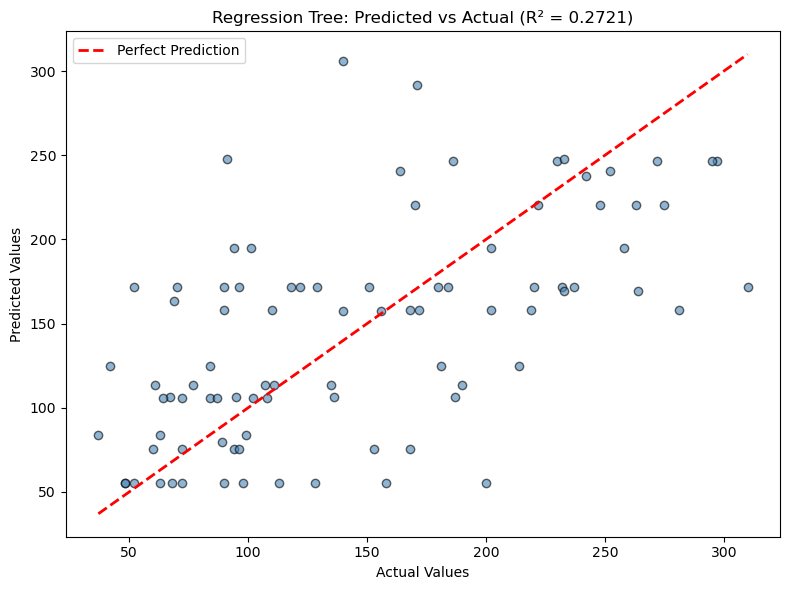

In [8]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', edgecolors='k')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Regression Tree: Predicted vs Actual (R² = {r2:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

## Visualizing the Step-Function Nature of Tree Predictions

Regression trees produce **piecewise-constant predictions** where each leaf outputs a single value. To visualize this, we'll fit a tree to a single feature and show its step-function output.

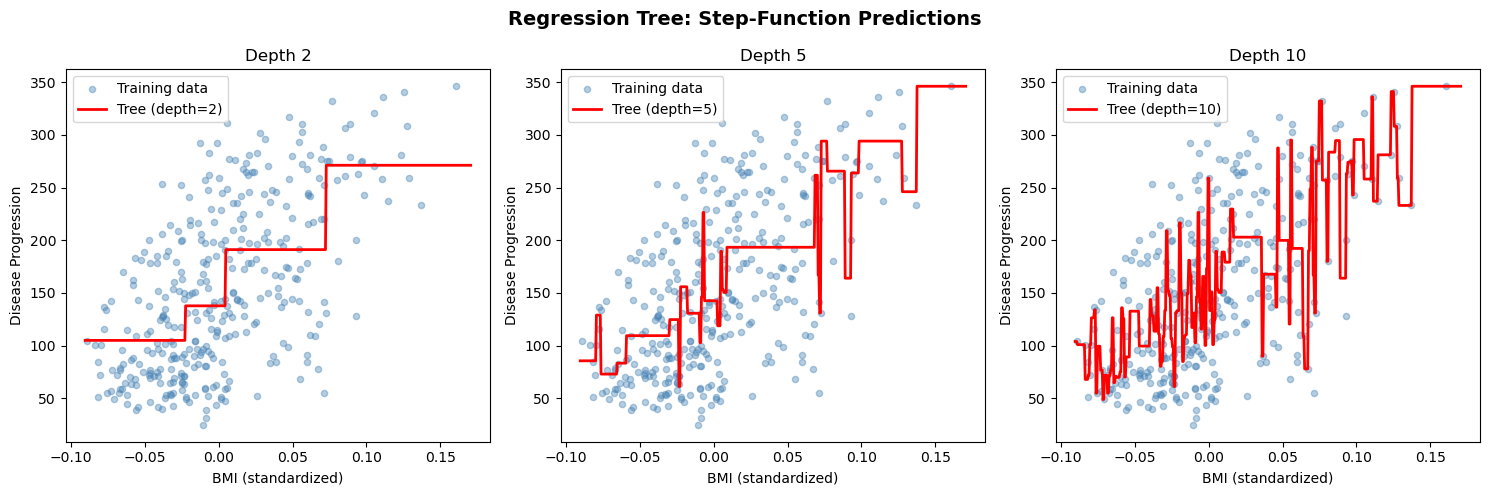

In [9]:
# Use only the BMI feature for visualization
X_bmi = X[:, 2:3]  # BMI is the 3rd feature
X_b_train, X_b_test, y_b_train, y_b_test = sklearn_split(
    X_bmi, y, test_size=0.2, random_state=42)

# Train trees of different depths
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
depths_viz = [2, 5, 10]

X_range = np.linspace(X_bmi.min(), X_bmi.max(), 500).reshape(-1, 1)

for ax, d in zip(axes, depths_viz):
    m = DecisionTreeRegressor(max_depth=d).fit(X_b_train, y_b_train)
    y_range = m.predict(X_range)

    ax.scatter(X_b_train, y_b_train, alpha=0.4,
               color='steelblue', s=20, label='Training data')
    ax.plot(X_range, y_range, color='red', linewidth=2,
            label=f'Tree (depth={d})')
    ax.set_xlabel('BMI (standardized)')
    ax.set_ylabel('Disease Progression')
    ax.set_title(f'Depth {d}')
    ax.legend()

plt.suptitle('Regression Tree: Step-Function Predictions',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Discussion

- The regression tree achieves **R² = 0.2721** at depth 5 on the diabetes dataset, which is lower than linear regression's 0.45, showing that a single shallow tree does not always outperform simpler models
- The **train vs test R² plot** dramatically illustrates the bias-variance tradeoff across depths
- At depth 1-2, both train and test R² are low (~0.13-0.27), which is clear **underfitting**
- At depth 3, test R² peaks at **0.3899**, which is the sweet spot for this dataset
- From depth 5 onwards, train R² climbs toward **1.0** while test R² collapses to **negative values** at depth 15-20, showing extreme **overfitting** where the tree memorizes every training point and fails completely on unseen data
- Negative R² means the model performs worse than simply predicting the mean, which is a sign of severe overfitting
- The optimal depth for this dataset is around **3**, not 5 as used in the main evaluation
- The **step-function visualization** perfectly illustrates how regression trees work at different depths
- At depth 2, only a few coarse steps are produced, missing most variation in the data
- At depth 5, a moderate number of steps captures more patterns
- At depth 10, extremely jagged predictions closely follow individual training points, showing clear overfitting
- The **predicted vs actual scatter plot** shows moderate positive correlation (R² = 0.2721) but with significant spread, meaning the tree captures some signal but high variance hurts generalization
- Compared to linear regression on this same dataset, linear regression achieved R² ≈ 0.45 with a smooth fit, outperforming the regression tree which struggles with high variance on this relatively small dataset
- **Strengths** include handling non-linear relationships, no feature scaling required, interpretability, and robustness to outliers
- **Weaknesses** include piecewise-constant predictions that are not smooth, extreme proneness to overfitting, and high variance, even more so than classification trees
- These limitations strongly motivate **ensemble methods** like Random Forests, which average many trees to dramatically reduce variance and produce more stable predictions